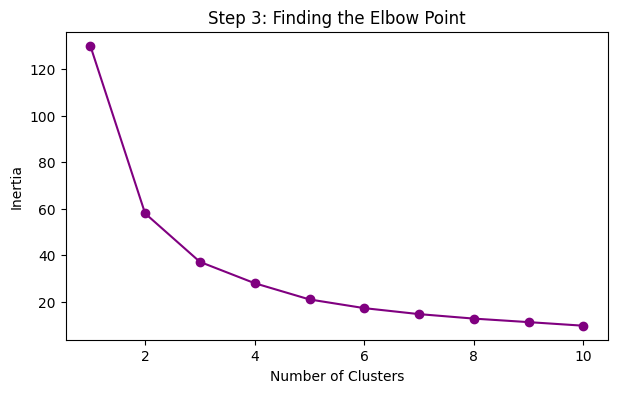

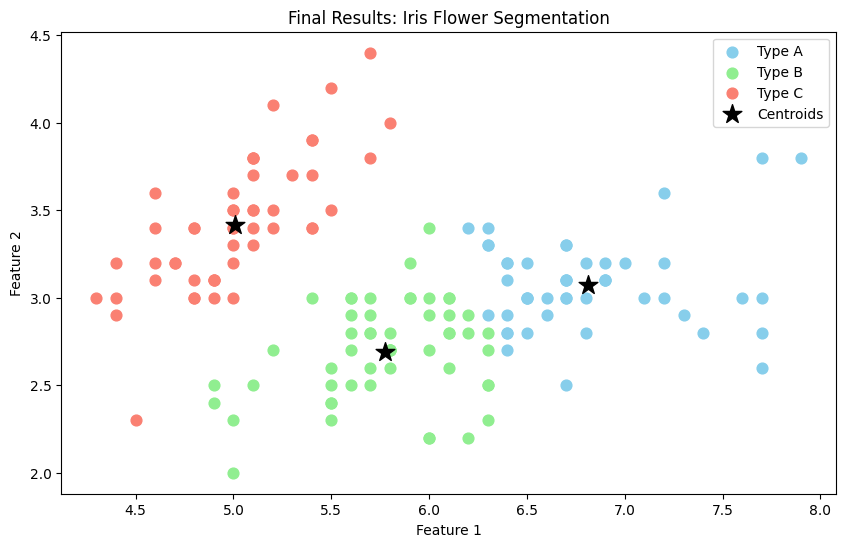

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Loading the flower data
# Using the clean filename 'iris.csv'
iris_df = pd.read_csv('iris.csv')

# Step 2: Selecting the numerical features
# I'm taking the first two columns (usually Sepal Length and Width)
plot_data = iris_df.iloc[:, [0, 1]].values

# Step 3: The Elbow Method to find the best cluster count
inertia_scores = []
for i in range(1, 11):
    # Using n_init=10 to avoid common sklearn warnings
    km_test = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km_test.fit(plot_data)
    inertia_scores.append(km_test.inertia_)

# Plotting the Elbow curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), inertia_scores, marker='o', color='purple')
plt.title('Step 3: Finding the Elbow Point')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Step 4: Applying K-Means with 3 clusters
# I chose 3 because that's where the elbow bends
final_km = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
my_clusters = final_km.fit_predict(plot_data)

# Step 5: Visualizing the final 3 groups
plt.figure(figsize=(10, 6))
plt.scatter(plot_data[my_clusters == 0, 0], plot_data[my_clusters == 0, 1], s=60, c='skyblue', label='Type A')
plt.scatter(plot_data[my_clusters == 1, 0], plot_data[my_clusters == 1, 1], s=60, c='lightgreen', label='Type B')
plt.scatter(plot_data[my_clusters == 2, 0], plot_data[my_clusters == 2, 1], s=60, c='salmon', label='Type C')

# Adding the 'Centers' as black stars
plt.scatter(final_km.cluster_centers_[:, 0], final_km.cluster_centers_[:, 1], s=200, c='black', marker='*', label='Centroids')

plt.title('Final Results: Iris Flower Segmentation')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()
